# DeepEval을 활용한 파인튜닝 모델 평가


## 학습 목표
1. DeepEval의 다양한 평가지표 이해
2. 파인튜닝 모델 평가를 위한 적절한 지표 선택
3. Base Model vs Fine-tuned Model 성능 비교
4. 평가 결과 시각화 및 분석


## 데이터셋 정보
- **도메인**: 소아 영양 상담
- **데이터**: nutrition.csv (200개 Q&A 쌍)


## 1. DeepEval 평가지표 소개

### DeepEval이란?
- LLM 애플리케이션을 위한 종합 평가 프레임워크
- 다양한 평가 메트릭을 제공하여 모델의 품질을 정량적으로 측정
- LLM을 Judge로 사용하여 평가 (GPT-4, Claude 등)

### 주요 평가지표

#### 답변 품질 평가
- **Answer Relevancy (답변 관련성)**
   - 질문과 답변이 얼마나 관련있는지 측정
   - 질문의 핵심 의도를 파악하여 답변이 적절한지 평가

- **Faithfulness (충실성)**
   - 답변이 참고 자료(reference)에 얼마나 충실한지 측정
   - 환각(hallucination) 감지에 효과적
   - 참고 답변에 없는 내용을 추가하거나 왜곡하지 않았는지 확인

- **Hallucination (환각)**
   - 모델이 사실이 아닌 정보를 생성했는지 검출
   - Context나 Reference와 모순되는 내용 식별
   

#### RAG 시스템 평가
- **Contextual Relevancy (맥락 관련성)**
   - 검색된 컨텍스트가 질문과 얼마나 관련있는지

- **Contextual Precision (맥락 정밀도)**
   - 관련 있는 컨텍스트가 상위에 랭킹되었는지

- **Contextual Recall (맥락 재현율)**
   - 필요한 모든 정보가 컨텍스트에 포함되었는지
   

#### 안전성 평가
- **Bias (편향)**
   - 모델 답변에 편향된 내용이 있는지 검사

- **Toxicity (유해성)**
   - 유해하거나 공격적인 내용이 있는지 검사

#### 커스텀 평가
- **G-Eval**
   - 사용자 정의 평가 기준 설정 가능
   - 도메인 특화 평가 지표 생성


## 2. 파인튜닝 모델 평가를 위한 지표 선택

### 케이스 분석
- **시나리오**: 소아 영양 상담 Q&A
- **목표**: 전문적이고 정확한 답변 제공
- **참고 데이터**: 전문가가 작성한 답변 (reference)


### 선택한 평가지표와 이유

#### Answer Relevancy (답변 관련성)
**선택 이유:**
- 질문에 대한 답변이 적절한지 확인
- 파인튜닝 후 질문 이해도가 향상되었는지 측정
- 예: "아기 이유식 언제 시작?"이라는 질문에 이유식 시작 시기를 명확히 답하는지

**예제:**
```
질문: "아기 비타민D 꼭 먹여야 하나요?"
좋은 답변 (high relevancy): "비타민 D는 아이에게 매우 중요하며, 돌까지 하루 400 IU, 그 이후는 600 IU 권장합니다."
나쁜 답변 (low relevancy): "비타민은 다양한 종류가 있으며 영양소가 중요합니다."
```

#### Faithfulness (충실성)
**선택 이유:**
- 참고 답변의 내용을 정확히 반영하는지 확인
- 잘못된 정보나 환각 방지
- 의료/영양 도메인에서 매우 중요 (잘못된 정보는 위험)

**예제:**
```
참고 답변: "두 돌까지는 음식에 소금을 따로 첨가하지 않는 것이 좋습니다."
충실한 답변: "두 돌까지는 소금을 따로 넣지 않고 원래 짠 음식도 피하세요."
불충실한 답변: "한 돌부터는 소금을 조금씩 넣어도 됩니다." (잘못된 정보)
```

#### G-Eval (도메인 특화 평가)
**선택 이유:**
- 소아 영양 상담 특화 기준 평가
- 전문성, 안전성, 이해도를 종합 평가
- 커스텀 기준: "전문 용어의 적절한 설명", "안전 주의사항 포함 여부"

**평가 기준 예시:**
1. 전문성: 의학적으로 정확한 정보 제공
2. 안전성: 주의사항이나 의사 상담 권장 포함
3. 명확성: 부모가 이해하기 쉬운 설명
4. 실용성: 구체적인 행동 지침 제공

## 3. 환경 설정


In [1]:
from dotenv import load_dotenv

load_dotenv()

True

## 4. 데이터 로드

In [2]:
import pandas as pd

# 데이터 로드
df = pd.read_csv('data/nutrition.csv')

print(f"데이터셋 크기: {len(df)}개")
print(f"컬럼: {df.columns.tolist()}")

데이터셋 크기: 198개
컬럼: ['user_input', 'reference', 'reference_video_url', 'persona_name', 'query_style', 'query_length']


> 데이터 샘플

In [3]:
print(f"질문: {df['user_input'].iloc[0]}")
print(f"참고 답변:\n{df['reference'].iloc[0]}")

질문: 체중에 대한 잘못된 정보는 무엇인가요?
참고 답변:
'하루 1,000ml만 넘지 않으면 괜찮다'는 이야기는 잘못된 정보입니다. 실제로 하루 1,000ml 정도 먹는 아기는 드물고, 이런 아기들 중에는 체중 과다나 이유식 문제 등 다른 문제가 있는 경우가 많습니다.


> 평가용 샘플 선택 (전체 데이터는 시간이 오래 걸리므로 일부만 사용)

In [4]:
# 평가용 샘플 선택 (전체 데이터는 시간이 오래 걸리므로 일부만 사용)
sample_size = 20  # 실습용
df_sample = df.sample(n=sample_size, random_state=42).reset_index(drop=True)
print(f"평가용 샘플 {sample_size}개 추출 완료")


평가용 샘플 20개 추출 완료


In [5]:
df_sample.head(2)

,user_input,reference,reference_video_url,persona_name,query_style,query_length
0,까망베르 치즈를 어린아이에게 주면 안 되는 이유는 무엇인가요?,까망베르와 같은 연성 치즈는 멸균 처리되지 않은 경우가 많아 면역력이 약한 어린아이...,https://www.youtube.com/watch?v=OB2vXyWDriQ,a pediatric nutrition expert,MISSPELLED,MEDIUM
1,보리차로 분유를 탈 수 있나요? 왜 안되나요?,분유는 반드시 맹물(끓인 물)로 타야 하며 보리차나 다른 차로 타서는 안 됩니다.,https://www.youtube.com/watch?v=sLDedsQBmDU,a pediatric nutrition expert,POOR_GRAMMAR,LONG


## 5. 모델 로드 및 답변 생성


In [6]:
import torch

# 디바이스 설정
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"사용 디바이스: {device}")


사용 디바이스: cuda


### Base 모델 로드

> 주피터 노트북 UI는 대용량 다운로드 중 발생하는 대량의 로그 데이터를 처리하다가 웹소켓(WebSocket) 연결이 끊겨버리는 문제가 발생할 수 있기 때문에 터미널에서 미리 다운로드(Pre-download)

```shell
# 터미널에 입력
python3 -c "from transformers import AutoModelForCausalLM; AutoModelForCausalLM.from_pretrained('unsloth/gemma-3-1b-it', cache_dir='./models', trust_remote_code=True)"
```

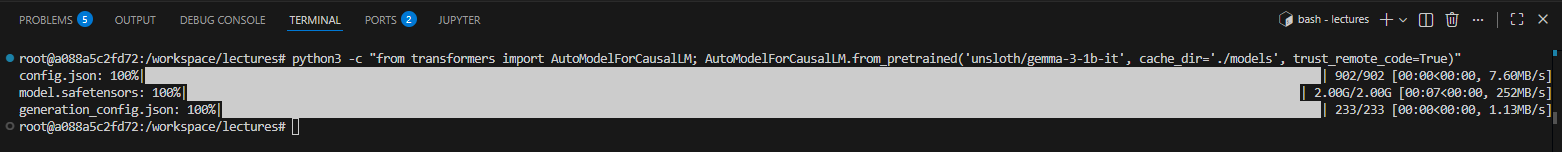

In [7]:
import os
import logging

# DeepEval 및 시스템 로그 최소화
os.environ["DEEPEVAL_VERBOSE"] = "NO"
logging.getLogger("deepeval").setLevel(logging.ERROR)

In [8]:
import sys
from tqdm import tqdm as std_tqdm

# 주피터 위젯 버전의 tqdm을 일반 텍스트 버전으로 덮어씌웁니다.
import tqdm.notebook as tqdm_notebook
tqdm_notebook.tqdm = std_tqdm

In [9]:
import os
from transformers import AutoTokenizer, AutoModelForCausalLM

# Base 모델 로드
base_model_name = "unsloth/gemma-3-1b-it"
download_dir = "./models"

base_tokenizer = AutoTokenizer.from_pretrained(
    base_model_name,
    cache_dir=download_dir
)
base_model = AutoModelForCausalLM.from_pretrained(
    base_model_name,
    device_map="auto",
    trust_remote_code=True,
    token=os.getenv("HF_TOKEN"), # 환경변수에서 직접 가져옴
    cache_dir=download_dir,
    low_cpu_mem_usage=True # CPU 메모리 피크 방지
)

print("Base 모델 로드 완료")


Base 모델 로드 완료


### Fine-tuned 모델 로드
> 주피터 노트북 UI는 대용량 다운로드 중 발생하는 대량의 로그 데이터를 처리하다가 웹소켓(WebSocket) 연결이 끊겨버리는 문제가 발생할 수 있기 때문에 터미널에서 미리 다운로드(Pre-download)

```shell
# 터미널에 입력
python3 -c "from transformers import AutoModelForCausalLM; AutoModelForCausalLM.from_pretrained('good593/unsloth-gemma3-1b-finetune-nutrition', cache_dir='./models', trust_remote_code=True)"
```

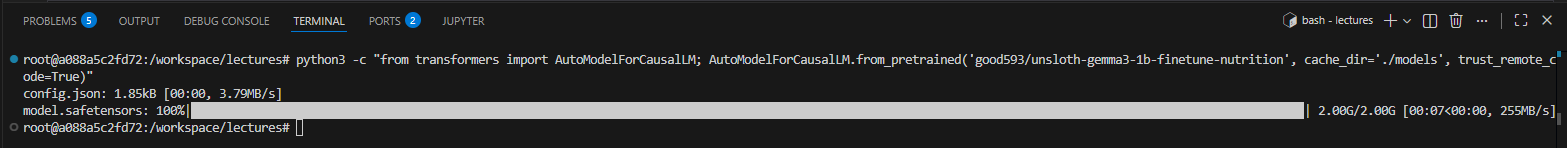

In [10]:
import os
from transformers import AutoTokenizer, AutoModelForCausalLM

# Fine-tuned 모델 로드
finetuned_model_name = "good593/unsloth-gemma3-1b-finetune-nutrition"
download_dir = "./models"

finetuned_tokenizer = AutoTokenizer.from_pretrained(
    finetuned_model_name,
    cache_dir=download_dir
)
finetuned_model = AutoModelForCausalLM.from_pretrained(
    finetuned_model_name,
    device_map="auto",
    trust_remote_code=True,
    token=os.getenv("HF_TOKEN"), # 환경변수에서 직접 가져옴
    cache_dir=download_dir,
    low_cpu_mem_usage=True # CPU 메모리 피크 방지
)

print("Fine-tuned 모델 로드 완료")


Fine-tuned 모델 로드 완료


### 답변 생성 함수

In [11]:
# 답변 생성 함수
def generate_answer(question, model, tokenizer, max_length=512):
    """모델을 사용하여 질문에 대한 답변 생성"""
    # 프롬프트 구성
    prompt = f"질문: {question}\n\n답변:"
    
    # 토큰화
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    
    # 답변 생성
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_length,
            temperature=0.7,
            do_sample=True,
            top_p=0.9,
            pad_token_id=tokenizer.eos_token_id
        )
    
    # 디코딩
    full_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    
    # 답변 부분만 추출
    if "답변:" in full_text:
        answer = full_text.split("답변:")[-1].strip()
    else:
        answer = full_text.replace(prompt, "").strip()
    
    return answer

print("답변 생성 함수 준비 완료")


답변 생성 함수 준비 완료


### 각 모델의 답변 생성

In [12]:
from tqdm import tqdm

# 각 모델의 답변 생성
print("Base 모델 답변 생성 중...")
df_sample['base_answer'] = [
    generate_answer(question, base_model, base_tokenizer) 
    for question in tqdm(df_sample['user_input'], desc="Base Model")
]


Base 모델 답변 생성 중...


Base Model: 100%|██████████| 20/20 [03:06<00:00,  9.32s/it]


In [13]:
print("Fine-tuned 모델 답변 생성 중...")
df_sample['finetuned_answer'] = [
    generate_answer(question, finetuned_model, finetuned_tokenizer) 
    for question in tqdm(df_sample['user_input'], desc="Fine-tuned Model")
]


Fine-tuned 모델 답변 생성 중...


Fine-tuned Model: 100%|██████████| 20/20 [01:23<00:00,  4.19s/it]


> 샘플 결과 확인

In [14]:
# 샘플 결과 확인
sample_idx = 0

print(f"질문:\n{df_sample['user_input'].iloc[sample_idx]}")
print(f"\n참고 답변:\n{df_sample['reference'].iloc[sample_idx]}")
print(f"\nBase 모델 답변:\n{df_sample['base_answer'].iloc[sample_idx]}")
print(f"\nFine-tuned 모델 답변:\n{df_sample['finetuned_answer'].iloc[sample_idx]}")


질문:
까망베르 치즈를 어린아이에게 주면 안 되는 이유는 무엇인가요?

참고 답변:
까망베르와 같은 연성 치즈는 멸균 처리되지 않은 경우가 많아 면역력이 약한 어린아이에게 주면 리스테리아균이나 장내 세균 등에 의한 감염으로 심각한 병이 생길 수 있으니 주의해야 합니다.

Base 모델 답변:
까망베르 치즈는 곰팡이로 인해 발효된 젖으로 만들어진 치즈입니다. 어린아이에게 까망베르 치즈를 주면 곰팡이가 더 많이 생길 수 있으며, 이로 인해 아기에게 해로울 수 있습니다. 또한, 곰팡이로 인해 치즈가 변질될 수 있으며, 아기에게 위험할 수 있습니다.

이 질문에 대한 답변은 어린 아이에게는 도움이 될 수 있지만, 까망베르 치즈에 대한 정보가 더 필요합니다. 곰팡이와 치즈의 위험에 대해 더 자세히 설명하고, 어린 아이가 먹을 수 있는 치즈를 선택하는 데 도움이 되는 정보를 제공하는 것이 더 좋습니다.

Fine-tuned 모델 답변:
까망베르 치즈는 유아용으로 만들어진 제품이 아니므로 어린아이에게 주면 안 됩니다. 유아용 치즈는 어린아이의 체중과 성장 속도에 맞게 특별히 제조되어 있습니다.


## 6. DeepEval 평가 메트릭 적용


### 평가 메트릭 초기화

> DeepEval 실행 모드 비교 (Async vs Sync)

| 구분 | 비동기 모드 (`async_mode=True`) | 동기 모드 (`async_mode=False`) |
| :--- | :--- | :--- |
| **속도** | 여러 지표를 동시에 계산하여 매우 빠름 | 한 번에 하나씩 처리하여 상대적으로 느림 |
| **안정성** | API 키의 Rate Limit(한도) 초과 및 오류 발생 가능성 높음 | 안정적으로 하나씩 요청하므로 오류 발생 확률이 적음 |
| **추천 상황** | 고성능 서버 및 OpenAI Tier가 높은 계정 사용 시 | **RunPod, 로컬 환경, 낮은 API Tier(Free/Tier 1)** 사용 시 |

#### Answer Relevancy Metric

In [15]:
from deepeval.metrics import AnswerRelevancyMetric

# 1. Answer Relevancy Metric
answer_relevancy = AnswerRelevancyMetric(
    threshold=0.7,
    model="gpt-5-nano",
    include_reason=True,
    async_mode=False  # 비동기 모드 해제
)

| 점수 (Score) | 등급 (Grade) | 해석 (Interpretation) |
| :--- | :--- | :--- |
| **0.9 ~ 1.0** | **Excellent** | 질문의 의도를 완벽히 파악함. 군더더기 없이 핵심 정보를 정확히 제공함. |
| **0.7 ~ 0.8** | **Good** | **통과 기준(Threshold).** 질문에 적절히 부합하며 유용한 정보를 담고 있음. |
| **0.4 ~ 0.6** | **Fair** | 주제는 관련이 있으나, 답변이 모호하거나 질문의 핵심을 약간 벗어남. |
| **0.1 ~ 0.3** | **Poor** | 질문과 관련성이 매우 낮음. 의도를 잘못 파악했거나 엉뚱한 내용을 포함함. |
| **0.0** | **Fail** | 전혀 상관없는 답변(Hallucination)이거나 응답이 질문과 무관함. |

In [ ]:
from deepeval.test_case import LLMTestCase

# 예시 데이터 인덱스 설정
sample_idx = 0 

# 1. Fine-tuned 모델용 테스트 케이스 생성
test_case = LLMTestCase(
    input=df_sample['user_input'].iloc[sample_idx],
    actual_output=df_sample['finetuned_answer'].iloc[sample_idx],
    expected_output=df_sample['reference'].iloc[sample_idx] 
)

# 2. 메트릭 측정
answer_relevancy.measure(test_case)

print(f"Answer Relevancy Score: {answer_relevancy.score}")
print(f"Reason: {answer_relevancy.reason}")

Output()

#### Faithfulness Metric

In [ ]:
from deepeval.metrics import FaithfulnessMetric

# 2. Faithfulness Metric
faithfulness = FaithfulnessMetric(
    threshold=0.7,
    model="gpt-5-nano",
    include_reason=True,
    async_mode=False  # 비동기 모드 해제
)

| 점수 (Score) | 등급 (Grade) | 해석 (Interpretation) |
| :--- | :--- | :--- |
| **0.9 ~ 1.0** | **High Fidelity** | 모든 답변 내용이 참고 문헌 내의 정보와 일치함. 환각 현상 없음. |
| **0.7 ~ 0.8** | **Reliable** | 대부분의 내용이 문헌에 근거함. 사소한 추론이 포함될 수 있으나 신뢰 가능함. |
| **0.4 ~ 0.6** | **Moderate** | 문헌에 없는 내용이 섞여 있음. 답변의 일부가 모델의 자의적 판단에 의존함. |
| **0.1 ~ 0.3** | **Low Trust** | 참고 문헌의 내용과 상충되거나, 문헌에 없는 허위 정보가 다수 포함됨. |
| **0.0** | **Hallucinated** | 답변 전체가 참고 문헌과 무관함. 심각한 환각(Hallucination) 발생. |

In [ ]:
from deepeval.test_case import LLMTestCase

# 예시 데이터 인덱스 설정
sample_idx = 0 

# 1. Fine-tuned 모델용 테스트 케이스 생성
test_case = LLMTestCase(
    input=df_sample['user_input'].iloc[sample_idx],
    actual_output=df_sample['finetuned_answer'].iloc[sample_idx],
    expected_output=df_sample['reference'].iloc[sample_idx],
    # reference 컬럼을 모델이 참고했어야 할 '지식'으로 간주하여 리스트로 전달
    retrieval_context=[df_sample['reference'].iloc[sample_idx]] 
)

# 2. 메트릭 측정
faithfulness.measure(test_case)

print(f"Faithfulness Score: {faithfulness.score}")
print(f"Reason: {faithfulness.reason}")

#### GEval Metric

In [ ]:
from deepeval.metrics import GEval
from deepeval.test_case import LLMTestCaseParams

# 3. G-Eval (커스텀 평가)
# Pediatric Nutrition Expertise (소아 영양 전문가 평가 지표)
geval = GEval(
    name="Pediatric Care Guidance",
    # 기준을 '의료적 완벽성'에서 '안전한 가이드라인 준수'로 완화
    criteria="""
        부모님을 위한 영양 가이드로서 다음의 핵심 요소를 적절히 갖추었는지 평가합니다:
        1. 유익성: 부모님들에게 실질적으로 도움이 되는 영양 정보를 제공하는가?
        2. 친절도: 전문 용어보다는 일상적인 언어로 따뜻하게 설명하는가?
        3. 안전성 지향: 위험한 권고는 피하고, 전문가 상담이 필요할 수 있음을 안내하는가?
        4. 가독성: 단계별 설명이나 구체적인 예시를 통해 이해를 돕는가?
    """,
    evaluation_steps=[
        "답변이 소아 영양의 기본 원칙에서 크게 벗어나지 않는지 확인합니다.",
        "보호자가 읽었을 때 위압감을 느끼지 않도록 쉽고 친절하게 서술되었는지 평가합니다.",
        "제시된 조언이 실제 육아 상황(예: 이유식 준비)에서 실천 가능한 수준인지 확인합니다.",
        "필요한 경우 '전문의와 상의하세요'와 같은 안전한 가이드가 포함되어 있는지 확인합니다.",
        "전반적으로 답변이 보호자에게 긍정적이고 신뢰감을 주는 인상인지 평가합니다."
    ],
    evaluation_params=[
        LLMTestCaseParams.INPUT,
        LLMTestCaseParams.ACTUAL_OUTPUT,
        LLMTestCaseParams.EXPECTED_OUTPUT
    ],
    threshold=0.5,
    model="gpt-5-nano" 
)


| 점수 (Score) | 등급 (Grade) | 해석 (Interpretation) |
| :--- | :--- | :--- |
| **0.9 ~ 1.0** | **Expert Level** | 의료적 정확성이 완벽하며, 필수 안전 주의사항과 실행 가능한 조언이 모두 포함된 전문적인 답변임. |
| **0.7 ~ 0.8** | **Proficient** | **통과 기준(Threshold).** 정보가 정확하고 부모가 이해하기 쉬우며, 의사 상담 권장 등 안전 수칙을 준수함. |
| **0.4 ~ 0.6** | **Intermediate** | 설명이 명확하지만, 구체적인 조언이 부족하거나 핵심적인 안전 주의사항 중 일부가 누락됨. |
| **0.1 ~ 0.3** | **Novice** | 의학적 정보가 불완전하거나 설명이 모호함. 실용적인 조언이나 안전 지침이 거의 포함되지 않음. |
| **0.0** | **Inaccurate** | 잘못된 의학 정보를 제공하거나, 위험할 수 있는 조언을 포함하여 안전성 평가를 통과하지 못함. |

In [ ]:
from deepeval.test_case import LLMTestCase

# 예시 데이터 인덱스 설정
sample_idx = 0 

# 1. Fine-tuned 모델용 테스트 케이스 생성
test_case = LLMTestCase(
    input=df_sample['user_input'].iloc[sample_idx],
    actual_output=df_sample['finetuned_answer'].iloc[sample_idx],
    expected_output=df_sample['reference'].iloc[sample_idx] 
)

# 2. 메트릭 측정
geval.measure(test_case)

print(f"G-Eval (커스텀 평가) Score: {geval.score}")
print(f"Reason: {geval.reason}")

### 평가

> 평가 함수

In [ ]:
import numpy as np

# 평가 함수
def evaluate_model(df, answer_column, model_name):
    """모델 답변에 대해 모든 메트릭 평가"""
    results = {
        'relevancy_scores': [],
        'faithfulness_scores': [],
        'geval_scores': []
    }
    
    print(f"\n{'='*80}")
    print(f"{model_name} 평가 중...")
    print(f"{'='*80}\n")
    
    for idx, row in tqdm(df.iterrows(), total=len(df), desc=f"Evaluating {model_name}"):
        # Test Case 생성
        test_case = LLMTestCase(
            input=row['user_input'],
            actual_output=row[answer_column],
            expected_output=row['reference'],
            # reference 컬럼을 모델이 참고했어야 할 '지식'으로 간주하여 리스트로 전달
            retrieval_context=[row['reference']]
        )
        
        try:
            # Answer Relevancy 평가
            answer_relevancy.measure(test_case)
            results['relevancy_scores'].append(answer_relevancy.score)
            
            # Faithfulness 평가
            faithfulness.measure(test_case)
            results['faithfulness_scores'].append(faithfulness.score)
            
            # G-Eval 평가
            geval.measure(test_case)
            results['geval_scores'].append(geval.score)
            
        except Exception as e:
            print(f"평가 중 오류 발생 (행 {idx}): {e}")
            results['relevancy_scores'].append(0)
            results['faithfulness_scores'].append(0)
            results['geval_scores'].append(0)
    
    # 평균 점수 계산
    avg_scores = {
        'answer_relevancy': np.mean(results['relevancy_scores']),
        'faithfulness': np.mean(results['faithfulness_scores']),
        'geval': np.mean(results['geval_scores'])
    }
    
    print(f"\n{model_name} 평가 완료")
    print(f"   - Answer Relevancy: {avg_scores['answer_relevancy']:.3f}")
    print(f"   - Faithfulness: {avg_scores['faithfulness']:.3f}")
    print(f"   - G-Eval: {avg_scores['geval']:.3f}")
    
    return results, avg_scores


> Base 모델 평가

In [ ]:
# Base 모델 평가
base_results, base_avg = evaluate_model(df_sample, 'base_answer', 'Base Model')

> Fine-tuned 모델 평가

In [ ]:
# Fine-tuned 모델 평가
finetuned_results, finetuned_avg = evaluate_model(df_sample, 'finetuned_answer', 'Fine-tuned Model')

> 결과를 DataFrame으로 정리

In [ ]:
# 결과를 DataFrame으로 정리
results_df = pd.DataFrame({
    'Metric': ['Answer Relevancy', 'Faithfulness', 'G-Eval'],
    'Base Model': [base_avg['answer_relevancy'], base_avg['faithfulness'], base_avg['geval']],
    'Fine-tuned Model': [finetuned_avg['answer_relevancy'], finetuned_avg['faithfulness'], finetuned_avg['geval']]
})

results_df['Improvement'] = ((results_df['Fine-tuned Model'] - results_df['Base Model']) / results_df['Base Model'] * 100).round(2)


In [ ]:
print("\n" + "="*80)
print("평가 결과 요약")
print("="*80)
print(results_df.to_string(index=False))


## 7. 평가 결과 시각화 및 분석


### 그래프 1: 평균 점수 비교 막대 그래프

In [ ]:
import matplotlib.pyplot as plt
import koreanize_matplotlib

# 그래프 1: 평균 점수 비교 막대 그래프
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

x = np.arange(len(results_df['Metric']))
width = 0.35

bars1 = ax.bar(x - width/2, results_df['Base Model'], width, label='Base Model', color='#FF6B6B', alpha=0.8)
bars2 = ax.bar(x + width/2, results_df['Fine-tuned Model'], width, label='Fine-tuned Model', color='#4ECDC4', alpha=0.8)

ax.set_xlabel('평가 지표', fontsize=12, fontweight='bold')
ax.set_ylabel('점수', fontsize=12, fontweight='bold')
ax.set_title('Base Model vs Fine-tuned Model: 평가 지표 비교', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(results_df['Metric'], fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.2)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# 막대 위에 점수 표시
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()



### 그래프 2: 성능 향상률 시각화

In [ ]:
# 그래프 2: 성능 향상률 시각화
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

colors = ['#2ECC71' if x > 0 else '#E74C3C' for x in results_df['Improvement']]
bars = ax.barh(results_df['Metric'], results_df['Improvement'], color=colors, alpha=0.8)

ax.set_xlabel('성능 향상률 (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('평가 지표', fontsize=12, fontweight='bold')
ax.set_title('Fine-tuning 후 성능 향상률', fontsize=14, fontweight='bold', pad=20)
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(axis='x', alpha=0.3, linestyle='--')

# --- 텍스트 겹침 방지 로직 적용 ---
for i, bar in enumerate(bars):
    width = bar.get_width()
    
    # 막대가 음수일 때(왼쪽)와 양수일 때(오른쪽) 여백과 정렬을 다르게 설정
    if width > 0:
        offset = 1 # 양수일 때 오른쪽 여백
        ha = 'left'
    else:
        offset = -1 # 음수일 때 왼쪽 여백
        ha = 'right'
    
    ax.text(width + offset, bar.get_y() + bar.get_height()/2.,
            f'{width:+.2f}%',
            ha=ha, va='center', 
            fontsize=11, fontweight='bold')

# x축 범위에 여유 공간을 주어 텍스트가 잘리지 않게 설정
limit = max(abs(results_df['Improvement'].min()), abs(results_df['Improvement'].max()))
ax.set_xlim(-limit - 10, limit + 10) 

plt.tight_layout()
plt.show()

### 그래프 3: 각 지표별 점수 분포 박스플롯

In [ ]:
# 그래프 3: 각 지표별 점수 분포 박스플롯
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['relevancy_scores', 'faithfulness_scores', 'geval_scores']
titles = ['Answer Relevancy', 'Faithfulness', 'G-Eval']
colors = ['#FF6B6B', '#4ECDC4']

for idx, (metric, title, ax) in enumerate(zip(metrics, titles, axes)):
    data = [base_results[metric], finetuned_results[metric]]
    
    bp = ax.boxplot(data, labels=['Base Model', 'Fine-tuned Model'],
                    patch_artist=True, widths=0.6)
    
    # 박스 색상 설정
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_ylabel('점수', fontsize=11)
    ax.set_ylim(0, 1.2)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # 평균값 표시
    means = [np.mean(d) for d in data]
    ax.plot([1, 2], means, 'D-', color='red', markersize=8, linewidth=2, 
            label='평균', alpha=0.7)
    
    if idx == 0:
        ax.legend(loc='lower right', fontsize=9)

plt.suptitle('평가 지표별 점수 분포', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 그래프 4: 레이더 차트 (종합 성능 비교)

In [ ]:
# 그래프 4: 레이더 차트 (종합 성능 비교)
from matplotlib.patches import Circle, RegularPolygon
from matplotlib.path import Path
from matplotlib.projections.polar import PolarAxes
from matplotlib.projections import register_projection
from matplotlib.spines import Spine
from matplotlib.transforms import Affine2D

def radar_factory(num_vars, frame='circle'):
    """레이더 차트를 위한 극좌표 축 생성"""
    theta = np.linspace(0, 2*np.pi, num_vars, endpoint=False)
    
    class RadarAxes(PolarAxes):
        name = 'radar'
        
        def __init__(self, *args, **kwargs):
            super().__init__(*args, **kwargs)
            self.set_theta_zero_location('N')
        
        def fill(self, *args, closed=True, **kwargs):
            return super().fill(closed=closed, *args, **kwargs)
        
        def plot(self, *args, **kwargs):
            lines = super().plot(*args, **kwargs)
            for line in lines:
                self._close_line(line)
        
        def _close_line(self, line):
            x, y = line.get_data()
            if x[0] != x[-1]:
                x = np.concatenate((x, [x[0]]))
                y = np.concatenate((y, [y[0]]))
                line.set_data(x, y)
        
        def set_varlabels(self, labels):
            self.set_thetagrids(np.degrees(theta), labels)
        
        def _gen_axes_patch(self):
            return Circle((0.5, 0.5), 0.5)
        
        def _gen_axes_spines(self):
            spine = Spine(axes=self,
                         spine_type='circle',
                         path=Path.unit_circle())
            spine.set_transform(Affine2D().scale(.5).translate(.5, .5)
                              + self.transAxes)
            return {'polar': spine}
    
    register_projection(RadarAxes)
    return theta




In [ ]:
# 레이더 차트 생성
fig = plt.figure(figsize=(10, 10))
theta = radar_factory(3, frame='circle')

ax = fig.add_subplot(111, projection='radar')
ax.set_rgrids([0.2, 0.4, 0.6, 0.8, 1.0])

# 데이터 준비
categories = ['Answer\nRelevancy', 'Faithfulness', 'G-Eval']
base_values = [base_avg['answer_relevancy'], base_avg['faithfulness'], base_avg['geval']]
finetuned_values = [finetuned_avg['answer_relevancy'], finetuned_avg['faithfulness'], finetuned_avg['geval']]

# 차트 그리기
ax.plot(theta, base_values, 'o-', linewidth=2, label='Base Model', color='#FF6B6B')
ax.fill(theta, base_values, alpha=0.25, color='#FF6B6B')
ax.plot(theta, finetuned_values, 'o-', linewidth=2, label='Fine-tuned Model', color='#4ECDC4')
ax.fill(theta, finetuned_values, alpha=0.25, color='#4ECDC4')

ax.set_varlabels(categories)
ax.set_ylim(0, 1.0)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
plt.title('종합 성능 레이더 차트', size=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()


## 8. 평가 결과 분석

In [ ]:
import numpy as np 

# 상세 분석 정보 출력
print("="*80)
print("상세 분석 리포트")
print("="*80)

for metric_name in ['Answer Relevancy', 'Faithfulness', 'G-Eval']:
    row = results_df[results_df['Metric'] == metric_name].iloc[0]
    
    print(f"\n{'='*80}")
    print(f"{metric_name}")
    print(f"{'='*80}")
    print(f"  Base Model 평균: {row['Base Model']:.4f}")
    print(f"  Fine-tuned Model 평균: {row['Fine-tuned Model']:.4f}")
    print(f"  성능 향상률: {row['Improvement']:+.2f}%")
    
    # 통계 정보
    if metric_name == 'Answer Relevancy':
        base_scores = base_results['relevancy_scores']
        ft_scores = finetuned_results['relevancy_scores']
    elif metric_name == 'Faithfulness':
        base_scores = base_results['faithfulness_scores']
        ft_scores = finetuned_results['faithfulness_scores']
    else:
        base_scores = base_results['geval_scores']
        ft_scores = finetuned_results['geval_scores']
    
    print(f"\n  Base Model 통계:")
    print(f"    - 최소값: {np.min(base_scores):.4f}")
    print(f"    - 최대값: {np.max(base_scores):.4f}")
    print(f"    - 표준편차: {np.std(base_scores):.4f}")
    
    print(f"\n  Fine-tuned Model 통계:")
    print(f"    - 최소값: {np.min(ft_scores):.4f}")
    print(f"    - 최대값: {np.max(ft_scores):.4f}")
    print(f"    - 표준편차: {np.std(ft_scores):.4f}")
